In [40]:
import pandas as pd

In [54]:
raw = pd.read_csv("/work/E2026/Intro_kurs/Long day data/combined_data.csv")

In [42]:
#raw.head(20)

In [6]:
#raw.tail(20)

In [44]:
list(raw)

['participant_id',
 'component_num',
 'url',
 'meta',
 'sender',
 'sender_type',
 'sender_id',
 'ended_on',
 'duration',
 'time_run',
 'time_render',
 'time_show',
 'time_end',
 'time_commit',
 'timestamp',
 'time_switch',
 'response',
 'response_action',
 'prime',
 'target',
 'condition',
 'soa_condition',
 'congruence',
 'correct_response',
 'correctResponse',
 'correct']

In [63]:
cols = ['participant_id','sender', 'target', 'duration', 'response', 'condition', 'soa_condition','congruence', 'correct_response', 'correct']

In [64]:
df = raw[cols]

In [65]:
df = df[df["sender"] == "target"]

In [66]:
df.head(5)

,participant_id,sender,target,duration,response,condition,soa_condition,congruence,correct_response,correct
13,51,target,SHEEP,843.38,n,practice,practice,practice,n,True
19,51,target,BOAT,593.04,m,practice,practice,practice,m,True
25,51,target,HOUSE,559.18,m,practice,practice,practice,m,True
31,51,target,HORSE,653.76,n,practice,practice,practice,n,True
40,51,target,PIANO,520.14,m,Inc_Synth_Synth,long,incongruent,m,True


In [67]:
sender_list = list(df["sender"])

In [68]:
set(sender_list)

{'target'}

In [69]:
df["sender"].unique()

<StringArray>
['target']
Length: 1, dtype: str

In [70]:
df = df[df["condition"] != "practice"]

In [71]:
df.head(10)

,participant_id,sender,target,duration,response,condition,soa_condition,congruence,correct_response,correct
40,51,target,PIANO,520.14,m,Inc_Synth_Synth,long,incongruent,m,True
47,51,target,BULL,640.66,n,Inc_Nat_Nat,long,incongruent,m,False
54,51,target,GOAT,597.74,n,Inc_Synth_Nat,long,incongruent,n,True
61,51,target,PEAR,495.68,n,Con_Nat,long,congruent,n,True
68,51,target,MOTOR,556.86,m,Inc_Nat_Synth,long,incongruent,m,True
75,51,target,REEF,553.82,n,Con_Nat,long,congruent,n,True
82,51,target,STONE,563.02,n,Con_Nat,long,congruent,n,True
89,51,target,PONY,746.32,n,Inc_Synth_Nat,long,incongruent,n,True
96,51,target,JEANS,464.46,m,Con_Synth,long,congruent,m,True
103,51,target,LION,666.96,n,Inc_Synth_Nat,long,incongruent,n,True


In [72]:
#df = df.drop(columns = ["sender"])
#df.head(10)

In [74]:
df.loc[df["target"] == "BULL", "correct response"] = "n"
df

,participant_id,sender,target,duration,response,condition,soa_condition,congruence,correct_response,correct,correct response
40,51,target,PIANO,520.14,m,Inc_Synth_Synth,long,incongruent,m,True,NaN
47,51,target,BULL,640.66,n,Inc_Nat_Nat,long,incongruent,m,False,n
54,51,target,GOAT,597.74,n,Inc_Synth_Nat,long,incongruent,n,True,NaN
61,51,target,PEAR,495.68,n,Con_Nat,long,congruent,n,True,NaN
68,51,target,MOTOR,556.86,m,Inc_Nat_Synth,long,incongruent,m,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...
15606,69,target,BELT,699.20,m,Con_Synth,short,congruent,m,True,NaN
15612,69,target,DAISY,580.20,n,Con_Nat,short,congruent,n,True,NaN
15618,69,target,SHED,577.90,m,Inc_Nat_Synth,short,incongruent,m,True,NaN
15624,69,target,HUSKY,661.10,n,Inc_Synth_Nat,short,incongruent,n,True,NaN


In [76]:
df["accuracy"] = df ["response"] == df["correct_response"]
df

,participant_id,sender,target,duration,response,condition,soa_condition,congruence,correct_response,correct,correct response,accuracy
40,51,target,PIANO,520.14,m,Inc_Synth_Synth,long,incongruent,m,True,NaN,True
47,51,target,BULL,640.66,n,Inc_Nat_Nat,long,incongruent,m,False,n,False
54,51,target,GOAT,597.74,n,Inc_Synth_Nat,long,incongruent,n,True,NaN,True
61,51,target,PEAR,495.68,n,Con_Nat,long,congruent,n,True,NaN,True
68,51,target,MOTOR,556.86,m,Inc_Nat_Synth,long,incongruent,m,True,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...
15606,69,target,BELT,699.20,m,Con_Synth,short,congruent,m,True,NaN,True
15612,69,target,DAISY,580.20,n,Con_Nat,short,congruent,n,True,NaN,True
15618,69,target,SHED,577.90,m,Inc_Nat_Synth,short,incongruent,m,True,NaN,True
15624,69,target,HUSKY,661.10,n,Inc_Synth_Nat,short,incongruent,n,True,NaN,True


In [79]:
df_grouped= df.groupby(["soa_condition", "congruence"]).mean(["duration"])

ValueError: numeric_only accepts only Boolean values

In [88]:
df_grouped = df.reset_index()
df_grouped

,index,participant_id,sender,target,duration,response,condition,soa_condition,congruence,correct_response,correct,correct response,accuracy
0,40,51,target,PIANO,520.14,m,Inc_Synth_Synth,long,incongruent,m,True,NaN,True
1,47,51,target,BULL,640.66,n,Inc_Nat_Nat,long,incongruent,m,False,n,False
2,54,51,target,GOAT,597.74,n,Inc_Synth_Nat,long,incongruent,n,True,NaN,True
3,61,51,target,PEAR,495.68,n,Con_Nat,long,congruent,n,True,NaN,True
4,68,51,target,MOTOR,556.86,m,Inc_Nat_Synth,long,incongruent,m,True,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2275,15606,69,target,BELT,699.20,m,Con_Synth,short,congruent,m,True,NaN,True
2276,15612,69,target,DAISY,580.20,n,Con_Nat,short,congruent,n,True,NaN,True
2277,15618,69,target,SHED,577.90,m,Inc_Nat_Synth,short,incongruent,m,True,NaN,True
2278,15624,69,target,HUSKY,661.10,n,Inc_Synth_Nat,short,incongruent,n,True,NaN,True


In [85]:
%pip install seaborn 

Note: you may need to restart the kernel to use updated packages.


In [86]:
import seaborn as sns

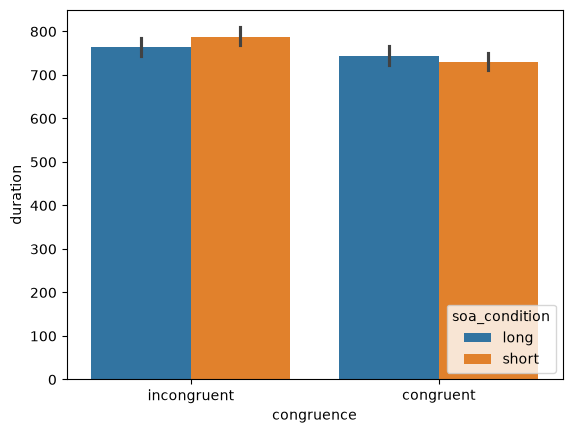

In [90]:
ax = sns.barplot(data = df_grouped, x = "congruence", y = "duration", hue = "soa_condition")
sns.move_legend(ax, "lower right")